# UK Electricity Price Forecasting
## Multi-City Random Forest Model + Streamlit Dashboard

This notebook:
1. Trains a Random Forest on hourly UK electricity prices + London historical weather
2. Fetches **live weather** from the Open-Meteo API for **8 UK cities** simultaneously
3. Generates next-day price forecasts for each city using that city's local weather
4. Saves all results to a JSON file that the Streamlit dashboard reads

**Why different cities get different forecasts:**
The UK electricity price is a national wholesale price, but each city contributes
differently to demand. A cold Birmingham winter morning drives more heating demand
than a mild Cardiff afternoon. The model uses each city's local weather (temperature,
wind, solar radiation) as features alongside the national price history.

**Files produced:**
- `rf_model.pkl` - trained Random Forest
- `feature_cols.json` - 37 feature names
- `price_history.csv` - last 200h of UK prices (for lag features)
- `city_forecasts.json` - next-day forecasts for all cities (Streamlit reads this)


## Step 1 -- Setup

In [1]:
# Standard library imports
import io
import json
import pickle
import time
import warnings
from urllib.error import URLError
from urllib.parse import urlencode
from urllib.request import urlopen
# Suppress unnecessary warning messages for cleaner output
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#Machine Learning Utilities
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#matplot style
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#e5e7eb", "axes.grid": True,
    "grid.color": "#f3f4f6", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlepad": 10, "figure.dpi": 120,
})
# Define reusable colors for charts and visual elements
BLUE, AMBER, GREEN, RED, GREY = "#2563eb","#d97706","#16a34a","#dc2626","#9ca3af"

# The 8 UK cities used for predictions
# Spread across England, Scotland, Wales, Northern Ireland
UK_CITIES = [
    {"name": "London",     "lat": 51.5074,  "lon": -0.1278,  "region": "England"},
    {"name": "Manchester", "lat": 53.4808,  "lon": -2.2426,  "region": "England"},
    {"name": "Birmingham", "lat": 52.4862,  "lon": -1.8904,  "region": "England"},
    {"name": "Leeds",      "lat": 53.8008,  "lon": -1.5491,  "region": "England"},
    {"name": "Bristol",    "lat": 51.4545,  "lon": -2.5879,  "region": "England"},
    {"name": "Edinburgh",  "lat": 55.9533,  "lon": -3.1883,  "region": "Scotland"},
    {"name": "Cardiff",    "lat": 51.4816,  "lon": -3.1791,  "region": "Wales"},
    {"name": "Belfast",    "lat": 54.5973,  "lon": -5.9301,  "region": "N. Ireland"},
]
# Display loaded city information
print(f"Cities loaded: {len(UK_CITIES)}")
for c in UK_CITIES:
    print(f"  {c['name']:<12} {c['region']:<12} lat={c['lat']:>7.4f}  lon={c['lon']:>8.4f}")


Cities loaded: 8
  London       England      lat=51.5074  lon= -0.1278
  Manchester   England      lat=53.4808  lon= -2.2426
  Birmingham   England      lat=52.4862  lon= -1.8904
  Leeds        England      lat=53.8008  lon= -1.5491
  Bristol      England      lat=51.4545  lon= -2.5879
  Edinburgh    Scotland     lat=55.9533  lon= -3.1883
  Cardiff      Wales        lat=51.4816  lon= -3.1791
  Belfast      N. Ireland   lat=54.5973  lon= -5.9301


## Step 2 -- Load Electricity Price Data

Load the hourly UK electricity prices. This is the national wholesale price --
the same value for all cities.


In [2]:
# File containing cleaned UK electricity pricing data
ELEC_PATH = "UK_Electricity_values.csv"
# Read CSV file into a pandas DataFrame and preprocess it
elec = pd.read_csv(ELEC_PATH)
# Rename the electricity price column for simplicity
# Keep only datetime and price columns
# Sort records chronologically
# Reset index after sorting
elec["dt"] = pd.to_datetime(elec["Datetime (Local)"], dayfirst=True)
elec = (elec.rename(columns={"Price (EUR/MWhe)": "price"})
            [["dt", "price"]]
            .sort_values("dt")
            .reset_index(drop=True))
# Display basic information about the dataset
print(f"Electricity rows:  {len(elec):,}")
print(f"Date range:        {elec.dt.min().date()} to {elec.dt.max().date()}")
print(f"Price range:       {elec.price.min():.1f} to {elec.price.max():.1f} EUR/MWh")
print(f"Mean price:        {elec.price.mean():.1f} EUR/MWh")
elec.tail(4)


Electricity rows:  86,198
Date range:        2016-06-30 to 2026-04-30
Price range:       -60.2 to 2575.9 EUR/MWh
Mean price:        94.7 EUR/MWh


,dt,price
86194,2026-04-30 20:00:00,128.23
86195,2026-04-30 21:00:00,119.51
86196,2026-04-30 22:00:00,104.27
86197,2026-04-30 23:00:00,98.17


## Step 3 -- Load Historical Weather (Training Data)

The model is **trained** using London weather data from 2016-2026.
At prediction time (Step 7), each city's own live weather is used instead.

This is acceptable because:
- Weather features contribute only ~9% of total feature importance
- The dominant features (60%+) are price lags -- the same national price for all cities
- Training on London weather teaches the model the general weather-demand relationship
- Local city weather then personalises predictions at inference time


In [3]:
# Geographic coordinates used for weather data collection
LONDON = {"lat": 51.5074, "lon": -0.1278}
# Historical weather fetch function
def fetch_historical_weather(lat, lon, start_date, end_date, timezone="Europe/London"):
    variables = ",".join([
        "temperature_2m", # Air temperature (°C)
        "precipitation", # Rainfall / precipitation (mm)
        "wind_speed_10m", # Wind speed at 10m height
        "shortwave_radiation", # Solar radiation (W/m²)
        "relative_humidity_2m",  # Relative humidity (%)
    ])
    # Store yearly chunks of weather data
    chunks = []
    # Convert input dates to pandas timestamps for easier manipulation
    current = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    # Open-Meteo performs better when requests are split into smaller ranges
    while current <= end:
        chunk_end = min(current + pd.DateOffset(years=1) - pd.Timedelta(days=1), end)
         # Build API request parameters
        params = urlencode({
            "latitude":   lat,
            "longitude":  lon,
            "start_date": current.strftime("%Y-%m-%d"),
            "end_date":   chunk_end.strftime("%Y-%m-%d"),
            "hourly":     variables,
            "timezone":   timezone,
        })
        # Construct Open-Meteo archive API URL
        url = f"https://archive-api.open-meteo.com/v1/archive?{params}"
        print(f"  Fetching {current.date()} to {chunk_end.date()}...", end=" ")
        try:
            # Send API request and load JSON response
            with urlopen(url, timeout=60) as resp:
                data = json.loads(resp.read())
            # Extract hourly weather data and convert to DataFrame
            h = data["hourly"]
            df_chunk = pd.DataFrame({
                "dt":       pd.to_datetime(h["time"]),
                "temp":     h["temperature_2m"],
                "precip":   h["precipitation"],
                "wind":     h["wind_speed_10m"],
                "solar":    h["shortwave_radiation"],
                "humidity": h["relative_humidity_2m"],
            })
            # Store chunk for later concatenation
            chunks.append(df_chunk)
            print(f"OK ({len(df_chunk)} rows)")
        except Exception as e:
            print(f"FAILED: {e}")
        # Move to the next yearly chunk
        current = chunk_end + pd.Timedelta(days=1)
        # Small delay to avoid overwhelming the API server
        time.sleep(0.5)
    if not chunks:
        raise RuntimeError("Failed to fetch any historical weather data from Open-Meteo")
    # Combine all chunks into one DataFrame and sort by datetime
    df = pd.concat(chunks, ignore_index=True)
    return df.sort_values("dt").reset_index(drop=True)
# Match weather dates with electricity price dataset
start_date = elec["dt"].min().strftime("%Y-%m-%d")
end_date   = elec["dt"].max().strftime("%Y-%m-%d")
# Fetch historical London weather
print(f"Fetching London historical weather: {start_date} to {end_date}")
print("(Fetching ~10 years in annual chunks -- takes about 30-60 seconds)")
weather_hist = fetch_historical_weather(LONDON["lat"], LONDON["lon"], start_date, end_date)
print(f"\nHistorical weather rows: {len(weather_hist):,}")
print(f"Date range: {weather_hist.dt.min().date()} to {weather_hist.dt.max().date()}")
print(f"Variables:  {list(weather_hist.columns)}")


Fetching London historical weather: 2016-06-30 to 2026-04-30
(Fetching ~10 years in annual chunks -- takes about 30-60 seconds)
  Fetching 2016-06-30 to 2017-06-29... OK (8760 rows)
  Fetching 2017-06-30 to 2018-06-29... OK (8760 rows)
  Fetching 2018-06-30 to 2019-06-29... OK (8760 rows)
  Fetching 2019-06-30 to 2020-06-29... OK (8784 rows)
  Fetching 2020-06-30 to 2021-06-29... OK (8760 rows)
  Fetching 2021-06-30 to 2022-06-29... OK (8760 rows)
  Fetching 2022-06-30 to 2023-06-29... OK (8760 rows)
  Fetching 2023-06-30 to 2024-06-29... OK (8784 rows)
  Fetching 2024-06-30 to 2025-06-29... OK (8760 rows)
  Fetching 2025-06-30 to 2026-04-30... OK (7320 rows)

Historical weather rows: 86,208
Date range: 2016-06-30 to 2026-04-30
Variables:  ['dt', 'temp', 'precip', 'wind', 'solar', 'humidity']


## Step 4 -- Feature Engineering

Builds all 37 features from hourly price + weather data.
The target is the price at the same hour tomorrow (24h ahead).
All lag features use data >= 24h old -- no data leakage.


In [4]:
# List of all input features used by the machine learning model
FCOLS = [
     # Calendar / time features
    "hour","dow","month","is_weekend","is_peak",
    "sin_h1","cos_h1","sin_h2","cos_h2","sin_h3","cos_h3", # Cyclical encoding of hours
    "sin_d1","cos_d1","sin_d2","cos_d2",  # Weekly Fourier features
    "sin_m1","cos_m1","sin_m2","cos_m2", # Monthly Fourier features
    "p_lag24","p_lag48","p_lag168",  # Historical price lags
    "p_roll_mean24","p_roll_std24","p_roll_mean168",  # Rolling price statistics
    "p_roll_min24","p_roll_max24","vol_regime",  
    "temp","wind","solar","humidity","precip",  # eather features
    "hdd","wind_sq","temp_lag24","wind_lag24",  # Derived weather features
]
# Feature engineering function
def build_features(price_df, weather_df):
    """
    Merge electricity prices with hourly weather and compute all 37 features.

    price_df:   DataFrame with [dt, price]
    weather_df: DataFrame with [dt, temp, wind, solar, humidity, precip]

    Returns (df_model, FCOLS) where df_model has all features + target column.
    """
    df = price_df.merge(weather_df, on="dt", how="left").sort_values("dt").reset_index(drop=True)

    # Fill minor weather gaps
    for col in ["temp","wind","solar","humidity","precip"]:
        if col not in df.columns:
            df[col] = 0.0
        else:
            df[col] = df[col].ffill().bfill().fillna(0.0)

    # Calendar
    df["hour"]       = df["dt"].dt.hour
    df["dow"]        = df["dt"].dt.dayofweek
    df["month"]      = df["dt"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["is_peak"]    = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

    # Fourier -- cyclic encoding so hour 23 and hour 0 are adjacent
    for k in [1,2,3]:
        df[f"sin_h{k}"] = np.sin(2*np.pi*k*df["hour"]/24)
        df[f"cos_h{k}"] = np.cos(2*np.pi*k*df["hour"]/24)
    for k in [1,2]:
        df[f"sin_d{k}"] = np.sin(2*np.pi*k*df["dow"]/7)
        df[f"cos_d{k}"] = np.cos(2*np.pi*k*df["dow"]/7)
        df[f"sin_m{k}"] = np.sin(2*np.pi*k*df["month"]/12)
        df[f"cos_m{k}"] = np.cos(2*np.pi*k*df["month"]/12)

    # Price lags -- all >= 24h to prevent leakage into target
    for lag in [24, 48, 168]:
        df[f"p_lag{lag}"] = df["price"].shift(lag)

    # Rolling statistics -- shift 24h first so no same-day price is used
    p24 = df["price"].shift(24)
    df["p_roll_mean24"]  = p24.rolling(24).mean()
    df["p_roll_std24"]   = p24.rolling(24).std()
    df["p_roll_mean168"] = p24.rolling(168).mean()
    df["p_roll_min24"]   = p24.rolling(24).min()
    df["p_roll_max24"]   = p24.rolling(24).max()

    std24  = p24.rolling(24).std()
    std168 = p24.rolling(168).std()
    df["vol_regime"] = (std24 / std168.replace(0, np.nan)).fillna(1.0).clip(0, 5)

    # Derived weather
    df["hdd"]        = np.maximum(0, 15.5 - df["temp"])   # heating degree hours
    df["wind_sq"]    = df["wind"] ** 2                     # wind generation proxy
    df["temp_lag24"] = df["temp"].shift(24)
    df["wind_lag24"] = df["wind"].shift(24)

    # Target: same-hour price tomorrow
    df["target"] = df["price"].shift(-24)

    df_model = df.dropna(subset=FCOLS + ["target"]).copy().reset_index(drop=True)
    return df_model

df = build_features(elec, weather_hist)
print(f"Feature matrix: {len(df):,} rows x {len(FCOLS)} features")
print(f"Date range:     {df.dt.min().date()} to {df.dt.max().date()}")


Feature matrix: 85,983 rows x 37 features
Date range:     2016-07-07 to 2026-04-29


## Step 5 -- Quick Exploratory Analysis

Text(0, 0.5, 'EUR / MWh')

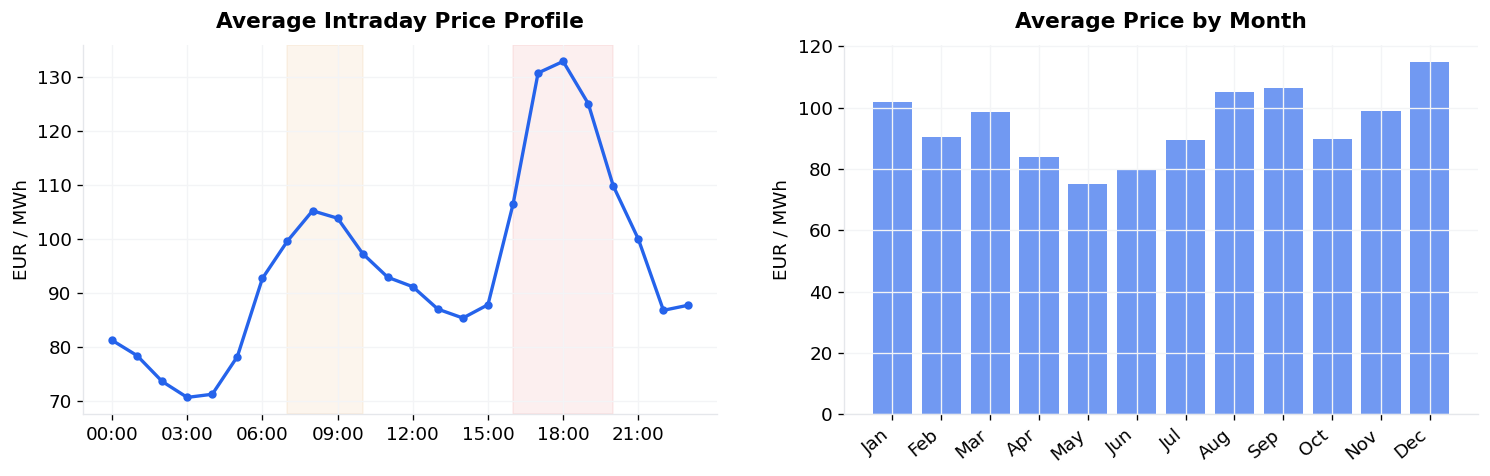

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Intraday profile
hourly_avg = df.groupby("hour")["price"].mean()
axes[0].plot(range(24), hourly_avg.values, color=BLUE, linewidth=2,
             marker="o", markersize=4)
axes[0].axvspan(7, 10, alpha=0.07, color=AMBER)
axes[0].axvspan(16, 20, alpha=0.07, color=RED)
axes[0].set_xticks(range(0,24,3))
axes[0].set_xticklabels([f"{h:02d}:00" for h in range(0,24,3)])
axes[0].set_title("Average Intraday Price Profile")
axes[0].set_ylabel("EUR / MWh")

# Seasonality
month_avg = df.groupby("month")["price"].mean()
mon = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(12), month_avg.values, color=BLUE, alpha=0.65)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(mon, rotation=40, ha="right")
axes[1].set_title("Average Price by Month")
axes[1].set_ylabel("EUR / MWh")



## Step 6 -- Train the Random Forest

Temporal split: train on 2016-2023, evaluate on 2024-2026.


In [6]:
# Train / test split based on time (train on 2015-2023, test on 2024)
SPLIT = pd.Timestamp("2024-01-01")
# Feature matrix and target
X = df[FCOLS] #input features
y = df["target"] #target variable (price 24h later)
# Create train/test masks based on the datetime split
tr = df["dt"] < SPLIT
te = df["dt"] >= SPLIT
# Display split information
print(f"Training: {tr.sum():,} hours  ({df[tr].dt.min().date()} to {df[tr].dt.max().date()})")
print(f"Test:     {te.sum():,} hours  ({df[te].dt.min().date()} to {df[te].dt.max().date()})")
print()
# Random Forest training setup
print("Training Random Forest (n=150, depth=12) -- approx 2 minutes...")
# Create Random Forest regression model
rf = RandomForestRegressor(
    n_estimators     = 150,  # Number of decision trees
    max_depth        = 12,   # Maximum depth of each tree
    min_samples_leaf = 8, # Minimum samples required in leaf nodes
    max_features     = 0.7, # Fraction of features to consider at each split
    random_state     = 42,  # Ensures reproducible results
    n_jobs           = -1, # Use all CPU cores for faster training
)
# Fit model using training data only
rf.fit(X[tr], y[tr])
print("Training complete.")


Training: 65,586 hours  (2016-07-07 to 2023-12-31)
Test:     20,397 hours  (2024-01-01 to 2026-04-29)

Training Random Forest (n=150, depth=12) -- approx 2 minutes...
Training complete.


In [7]:
# Model evaluation on test set
# Generate predictions using unseen test data
preds_te = rf.predict(X[te])
# Actual target values from the test set
act_te   = y[te].values
# Mean Absolute Error (MAE)
mae  = mean_absolute_error(act_te, preds_te)
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(act_te, preds_te))
# R-squared score (R²)
r2   = r2_score(act_te, preds_te)
# Mean Absolute Percentage Error (MAPE)
# Exclude near-zero electricity prices
# to avoid unstable percentage calculations
nz   = np.abs(act_te) > 5
mape = np.mean(np.abs((act_te[nz]-preds_te[nz])/act_te[nz]))*100
# Display evaluation results
print("Test set performance (Jan 2024 - Mar 2026):")
print(f"  MAE:  {mae:.2f} EUR/MWh")
print(f"  RMSE: {rmse:.2f} EUR/MWh")
print(f"  R2:   {r2:.3f}  ({r2*100:.0f}% of variance explained)")
print(f"  MAPE: {mape:.1f}%  (prices > 5 EUR/MWh only)")


Test set performance (Jan 2024 - Mar 2026):
  MAE:  19.19 EUR/MWh
  RMSE: 31.89 EUR/MWh
  R2:   0.341  (34% of variance explained)
  MAPE: 41.4%  (prices > 5 EUR/MWh only)


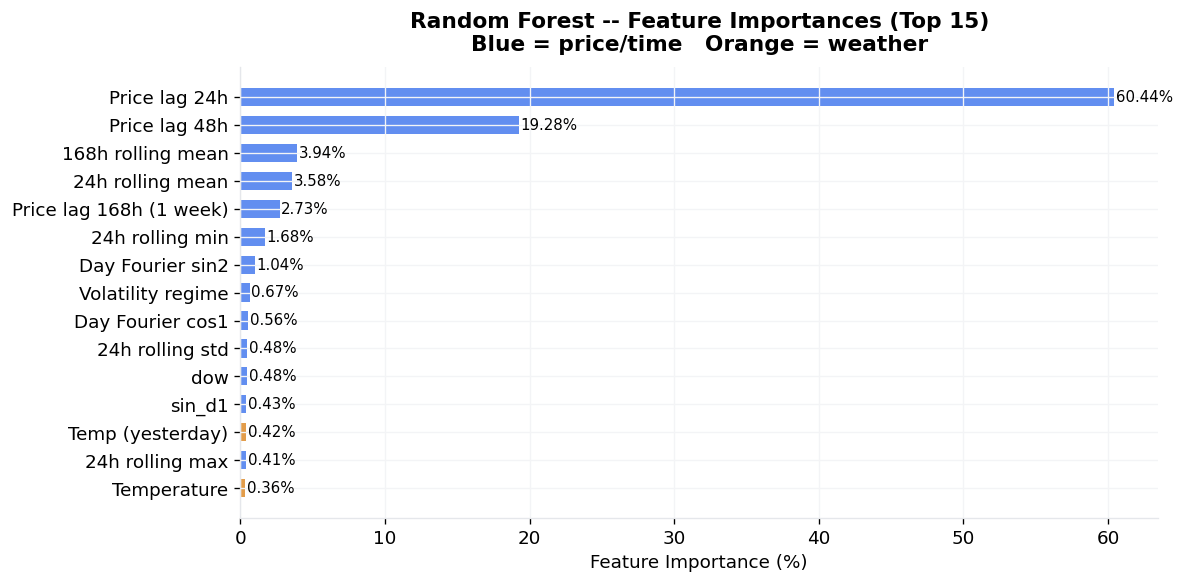

Weather features total importance: 2.4%
Price/time features:               97.6%


In [8]:
# Feature importance analysis
# Extract feature importance scores
# from the trained Random Forest model
fi = (pd.DataFrame({"feature": FCOLS, "importance": rf.feature_importances_})
        .sort_values("importance", ascending=False))
# Weather-related feature set for coloring the importance chart
WX = {"wind","wind_sq","wind_lag24","temp","temp_lag24","hdd","solar","humidity","precip"}
# Human-readable feature labels for better visualization
NAME = {
    "p_lag24":"Price lag 24h", "p_lag48":"Price lag 48h", # Price lag features
    "p_lag168":"Price lag 168h (1 week)",
    "p_roll_mean24":"24h rolling mean", "p_roll_std24":"24h rolling std", "p_roll_mean168":"168h rolling mean",
    "p_roll_min24":"24h rolling min", "p_roll_max24":"24h rolling max",  # Rolling statistics
    "vol_regime":"Volatility regime", "wind":"Wind speed",  # Volatility
    "wind_sq":"Wind^2", "wind_lag24":"Wind (yesterday)", "temp":"Temperature", "temp_lag24":"Temp (yesterday)", # Weather features
    "hdd":"Heating degree hours", "solar":"Solar radiation", "humidity":"Humidity",
    "sin_h1":"Hour Fourier sin1", "cos_d1":"Day Fourier cos1", # Fourier time encodings
    "sin_d2":"Day Fourier sin2", "is_peak":"Is peak hour", "is_weekend":"Is weekend",   # Binary calendar indicators
}
# Create readable labels for the top 15 features, using the NAME mapping where available
fi["label"] = fi["feature"].map(NAME).fillna(fi["feature"])
# Select top 15 most important features
top15 = fi.head(15)
# Plot feature importances with color coding for weather vs price/time features
fig, ax = plt.subplots(figsize=(10, 5))
# Price/time features shown in blue
cols = [AMBER if f in WX else BLUE for f in top15["feature"]]
# Horizontal bar chart
bars = ax.barh(top15["label"], top15["importance"]*100, color=cols, alpha=0.72, height=0.65)
# Axis labels and chart title
ax.set_xlabel("Feature Importance (%)")
ax.set_title("Random Forest -- Feature Importances (Top 15)\nBlue = price/time   Orange = weather")
ax.invert_yaxis()
# Add percentage labels to bars
for bar, val in zip(bars, top15["importance"]*100):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2, f"{val:.2f}%", va="center", fontsize=9)
# Adjust layout spacing
plt.tight_layout()
# Save chart to file
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
# Calculate total contribution from weather-related features
wx_total = fi[fi["feature"].isin(WX)]["importance"].sum()*100
print(f"Weather features total importance: {wx_total:.1f}%")
print(f"Price/time features:               {100-wx_total:.1f}%")


## Step 7 -- Save Model Artifacts

In [9]:
# Save trained Random Forest model and feature columns for later use in the API

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)
# Store feature names used during training
with open("feature_cols.json", "w") as f:
    json.dump(FCOLS, f)

#This file is used by the forecasting app
# to generate next-day predictions.
price_history = (
    elec[["dt", "price"]]          # Keep only required columns
    .sort_values("dt")             # Ensure chronological ordering
    .tail(200)                     # Keep latest 200 hourly records
    .copy()                        # Create independent copy
    .reset_index(drop=True)        # Reset row numbering
)
# Save history file
price_history.to_csv("price_history.csv", index=False)
# Display saved history details
print(f"price_history.csv saved")
print(f"  Rows:      {len(price_history)}")
print(f"  From:      {price_history['dt'].min()}")
print(f"  To:        {price_history['dt'].max()}")
print(f"  Predicts:  {(price_history['dt'].max() + pd.Timedelta(hours=1)).date()} onwards")
print()

# List of generated model artifacts and their sizes
import os
for fname in ["rf_model.pkl", "feature_cols.json", "price_history.csv"]:
    size = os.path.getsize(fname)   # File size in bytes
    print(f"  {fname:<25} {size/1024:.0f} KB")
print("All artifacts saved.")


price_history.csv saved
  Rows:      200
  From:      2026-04-22 16:00:00
  To:        2026-04-30 23:00:00
  Predicts:  2026-05-01 onwards

  rf_model.pkl              21993 KB
  feature_cols.json         0 KB
  price_history.csv         5 KB
All artifacts saved.


## Step 7b -- Fetch Missing Prices to Enable Next-Day Prediction

The electricity CSV may be several days behind today.
This cell automatically fetches the missing days from the
Energy-Charts API (Fraunhofer ISE -- free, no API key required)
and updates `price_history.csv` so the model always predicts tomorrow.

If the API is unavailable the last known data is used as a fallback.


In [10]:
# Additional imports
import json as _json
import datetime
import pandas as pd
from urllib.request import urlopen
from urllib.parse import urlencode

# Missing electricity price fetcher
def fetch_missing_prices(start_date, end_date):
    """
    Fetch UK day-ahead prices from Energy-Charts API (Fraunhofer ISE).
    Completely free, no registration or API key required.
    Returns DataFrame [dt, price] or None on failure.
    """
    # API expects UTC timestamps
    start_str = start_date.strftime("%Y-%m-%dT00:00Z")
    end_str   = end_date.strftime("%Y-%m-%dT23:00Z")
    # Build API request
    params    = urlencode({"bzn": "GB", "start": start_str, "end": end_str})
    url       = "https://api.energy-charts.info/price?" + params

    try:
        with urlopen(url, timeout=15) as r:
            data = _json.loads(r.read())
        # Convert API response to DataFrame and adjust timezones
        df = pd.DataFrame({
            "dt":    pd.to_datetime(data["unix_seconds"], unit="s", utc=True)
                       .tz_convert("Europe/London")
                       .tz_localize(None),
            "price": data["price"],
        })
        df["dt"] = df["dt"].dt.floor("h")
        df = df.drop_duplicates("dt").dropna().reset_index(drop=True)
        return df

    except Exception as e:
        print(f"  API fetch failed: {e}")
        return None


# Load the full cleaned electricity file
elec_full = pd.read_csv(ELEC_PATH)
# Convert datetime column
elec_full["dt"]    = pd.to_datetime(elec_full["Datetime (Local)"])
# Standardize price column name and keep only necessary columns
elec_full["price"] = elec_full["Price (EUR/MWhe)"]
# Keep only required columns
elec_full = elec_full[["dt", "price"]].sort_values("dt").reset_index(drop=True)
# Determine missing date range for price data
last_known = elec_full["dt"].max()
today      = pd.Timestamp.now().normalize()
yesterday  = today - pd.Timedelta(days=1)
# Display status information
print(f"Last known price:  {last_known}")
print(f"Today:             {today.date()}")
# Number of missing hours
gap_hours = int((yesterday - last_known).total_seconds() / 3600)
print(f"Gap:               {gap_hours} hours  ({max(0, (yesterday.date() - last_known.date()).days)} days)")
# Fetch missing electricity prices
if gap_hours <= 0:
    print("Data is already up to date -- no fetch needed.")
    combined = elec_full.copy()

else:
    fetch_start = (last_known + pd.Timedelta(hours=1)).date()
    fetch_end   = yesterday.date()
    print(f"Fetching {fetch_start} to {fetch_end} from Energy-Charts API...")

    new_prices = fetch_missing_prices(fetch_start, fetch_end)

    if new_prices is not None and len(new_prices) > 0:
        print(f"  Fetched: {len(new_prices)} hourly prices")
        print(f"  Range:   {new_prices.dt.min()} to {new_prices.dt.max()}")
        combined = (pd.concat([elec_full, new_prices], ignore_index=True)
                      .drop_duplicates("dt")
                      .sort_values("dt")
                      .reset_index(drop=True))
        print(f"  Combined total: {len(combined):,} rows")
    else:
        print("  API unavailable -- using existing data only.")
        combined = elec_full.copy()

# Save the updated price_history.csv 
price_history = combined.tail(200).copy().reset_index(drop=True)
price_history.to_csv("price_history.csv", index=False)
# Prediction metadata
last_dt   = price_history["dt"].max()
pred_date = last_dt.date() + datetime.timedelta(days=1)
# Display final summary
print()
print(f"price_history.csv updated")
print(f"  Covers:     {price_history['dt'].min()}  to  {last_dt}")
print(f"  Predicts:   {pred_date}  (tomorrow)")
print(f"  Last price: {price_history['price'].iloc[-1]:.2f} EUR/MWh")

# Reload so Step 9 uses the freshest data
price_history = pd.read_csv("price_history.csv", parse_dates=["dt"])


Last known price:  2026-04-30 23:00:00
Today:             2026-05-07
Gap:               121 hours  (6 days)
Fetching 2026-05-01 to 2026-05-06 from Energy-Charts API...
  API fetch failed: HTTP Error 400: Bad Request
  API unavailable -- using existing data only.

price_history.csv updated
  Covers:     2026-04-22 16:00:00  to  2026-04-30 23:00:00
  Predicts:   2026-05-01  (tomorrow)
  Last price: 98.17 EUR/MWh


## Step 8 -- Live Weather API

Fetches current + forecast hourly weather for all 8 UK cities from Open-Meteo.
Free, no API key required.

`past_days=8` ensures we always have enough data to compute the 168-hour lag features.


In [11]:
# Fetch weather data for one city
def fetch_city_weather(city):
    """
    Fetch past 8 days + 2 forecast days of hourly weather for a city.
    Returns DataFrame [dt, temp, precip, wind, solar, humidity] or None on failure.
    """
    variables = ",".join([
        "temperature_2m", "precipitation",
        "wind_speed_10m", "shortwave_radiation",
        "relative_humidity_2m",
    ])
    # Build API request
    params = urlencode({
        # Geographic coordinates
        "latitude":      city["lat"],
        "longitude":     city["lon"],
         # Requested weather variables
        "hourly":        variables,
         # Historical + forecast range
        "past_days":     8,
        "forecast_days": 2,
        # Local UK timezone
        "timezone":      "Europe/London",
    })
     # Open-Meteo forecast endpoint
    url = f"https://api.open-meteo.com/v1/forecast?{params}"
    try:
        # Send API request
        with urlopen(url, timeout=15) as resp:
            data = json.loads(resp.read())
        h = data["hourly"]
        # Convert response to DataFrame
        df = pd.DataFrame({
            # Weather variables
            "dt":       pd.to_datetime(h["time"]),
            "temp":     h["temperature_2m"],
            "precip":   h["precipitation"],
            "wind":     h["wind_speed_10m"],
            "solar":    h["shortwave_radiation"],
            "humidity": h["relative_humidity_2m"],
        })
        return df.sort_values("dt").reset_index(drop=True)
    except Exception as e:
        print(f"    Warning -- could not fetch weather for {city['name']}: {e}")
        return None

# Fetch weather for all cities
def fetch_all_cities(cities, delay=0.5):
    """
    Fetch weather for all cities with a small delay between requests
    """
     # Store weather results
    results = {}
    # Loop through each city
    for city in cities:
        print(f"  Fetching weather for {city['name']}...", end=" ")
        # Fetch city weather
        wx = fetch_city_weather(city)
        if wx is not None:
            # Store DataFrame
            results[city["name"]] = wx
            print(f"OK  ({len(wx)} rows, {wx.dt.min().date()} to {wx.dt.max().date()})")
        # Failed request
        else:
            print("FAILED")
        # Small delay between requests
        time.sleep(delay)
    return results
# Fetch weather data for all UK cities
print("Fetching live weather for all UK cities...")
city_weather = fetch_all_cities(UK_CITIES)
# Display final summary
print(f"\nSuccessfully fetched weather for {len(city_weather)}/{len(UK_CITIES)} cities.")


Fetching live weather for all UK cities...
  Fetching weather for London... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Manchester... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Birmingham... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Leeds... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Bristol... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Edinburgh... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Cardiff... OK  (240 rows, 2026-04-29 to 2026-05-08)
  Fetching weather for Belfast... OK  (240 rows, 2026-04-29 to 2026-05-08)

Successfully fetched weather for 8/8 cities.


## Step 9 -- Build Prediction Features Per City

For each city, merge the national price history with that city's local weather
and compute all 37 features. The last 24 rows (today's hours) are used to
predict tomorrow's 24 hourly prices.


In [12]:
# Used as the base signal for lag features
price_history = pd.read_csv("price_history.csv", parse_dates=["dt"])

# City-level forecasting function
def predict_city(city_name, city_weather_df, price_hist, model, fcols):
    """
    Build features for a city and predict next-day hourly prices.

    Handles the case where price_hist has a gap between the last known price
    and today. Missing prices are estimated using the same-hour-last-week value
    (p_lag168), which preserves the weekly seasonal pattern without introducing
    data leakage. This allows the model to produce a genuine next-day forecast
    even when the electricity CSV is several days out of date.
    """
    # Outer merge so tomorrow weather hours are included
    df = (price_hist
          .merge(city_weather_df, on="dt", how="outer")
          .sort_values("dt")
          .reset_index(drop=True))

    # Fill weather gaps
    for col in ["temp", "wind", "solar", "humidity", "precip"]:
        if col not in df.columns:
            df[col] = 0.0
        else:
            df[col] = df[col].ffill().bfill().fillna(0.0)

    # Fill price gap with same-hour-last-week estimate 
    # When electricity data is outdated,
    # fill missing values using:
    # → same hour last week (168h lag)
    df["price_filled"] = df["price"].copy()
    for _ in range(7):   # iterate to fill multiple missing weeks if needed
        gap = df["price_filled"].isna()
        if not gap.any():
            break
        df.loc[gap, "price_filled"] = df["price_filled"].shift(168)[gap]
    df["price_filled"] = df["price_filled"].ffill().bfill()

    # Use price_filled for ALL lag and rolling computations
    p = df["price_filled"]

    # Calendar
    df["hour"]       = df["dt"].dt.hour
    df["dow"]        = df["dt"].dt.dayofweek
    df["month"]      = df["dt"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["is_peak"]    = df["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

    # Fourier encoding
    for k in [1, 2, 3]:
        df["sin_h" + str(k)] = np.sin(2 * np.pi * k * df["hour"] / 24)
        df["cos_h" + str(k)] = np.cos(2 * np.pi * k * df["hour"] / 24)
    for k in [1, 2]:
        df["sin_d" + str(k)] = np.sin(2 * np.pi * k * df["dow"]   / 7)
        df["cos_d" + str(k)] = np.cos(2 * np.pi * k * df["dow"]   / 7)
        df["sin_m" + str(k)] = np.sin(2 * np.pi * k * df["month"] / 12)
        df["cos_m" + str(k)] = np.cos(2 * np.pi * k * df["month"] / 12)

    # Price lags -- computed on filled prices to avoid NaN cascade
    for lag in [24, 48, 168]:
        df["p_lag" + str(lag)] = p.shift(lag)
    # Rolling statistics
    p24 = p.shift(24)
    df["p_roll_mean24"]  = p24.rolling(24).mean()
    df["p_roll_std24"]   = p24.rolling(24).std()
    df["p_roll_mean168"] = p24.rolling(168).mean()
    df["p_roll_min24"]   = p24.rolling(24).min()
    df["p_roll_max24"]   = p24.rolling(24).max()

    std24  = p24.rolling(24).std()
    std168 = p24.rolling(168).std()
    df["vol_regime"] = (std24 / std168.replace(0, np.nan)).fillna(1.0).clip(0, 5)

    # Derived weather
    df["hdd"]        = np.maximum(0, 15.5 - df["temp"])
    df["wind_sq"]    = df["wind"] ** 2
    df["temp_lag24"] = df["temp"].shift(24)
    df["wind_lag24"] = df["wind"].shift(24)

    # ── Select today's 24 hours as the feature rows ───────────────────────────
    # Prefer today's full 24h block
    today      = pd.Timestamp.now().normalize()
    tomorrow   = today + pd.Timedelta(days=1)
    today_mask = (df["dt"] >= today) & (df["dt"] < tomorrow)

    feats = df[today_mask].dropna(subset=fcols)

    # Fallback: if today's hours aren't all available yet use last 24 valid rows
    if len(feats) < 24:
        feats = df.dropna(subset=fcols).tail(24)

    if len(feats) < 24:
        return None

    feats = feats.head(24).copy().reset_index(drop=True)
    # Model prediction
    prices   = model.predict(feats[fcols])
    # Shift to next-day timestamps
    pred_dts = feats["dt"] + pd.Timedelta(hours=24)
    # Output forecast DataFrame
    return pd.DataFrame({
        "pred_dt":  pred_dts,
        "hour":     pred_dts.dt.hour,
        "price":    np.round(prices, 2),
        "temp":     feats["temp"].values.round(1),
        "wind":     feats["wind"].values.round(1),
        "solar":    feats["solar"].values.round(1),
        "humidity": feats["humidity"].values.round(1),
    })

# Run forecasts for all cities
print("Running predictions for all cities...")
city_forecasts = {}

for city in UK_CITIES:
    name = city["name"]
    if name not in city_weather:
        print(f"  {name:<12} SKIPPED (no weather data)")
        continue
    fc = predict_city(name, city_weather[name], price_history, rf, FCOLS)
    if fc is not None:
        city_forecasts[name] = fc
        pred_date = fc["pred_dt"].iloc[0].strftime("%Y-%m-%d")
        print(f"  {name:<12} OK  date={pred_date}  "
              f"mean={fc.price.mean():.1f}  "
              f"peak={fc.price.max():.1f}@{int(fc.loc[fc.price.idxmax(), 'hour']):02d}:00")
    else:
        print(f"  {name:<12} FAILED (not enough lag data)")
# Final summary of forecasts
print(f"\nForecasts ready for {len(city_forecasts)} cities.")


Running predictions for all cities...
  London       OK  date=2026-05-08  mean=100.6  peak=129.0@19:00
  Manchester   OK  date=2026-05-08  mean=100.8  peak=129.7@19:00
  Birmingham   OK  date=2026-05-08  mean=101.2  peak=129.7@19:00
  Leeds        OK  date=2026-05-08  mean=100.9  peak=129.8@19:00
  Bristol      OK  date=2026-05-08  mean=100.6  peak=129.2@19:00
  Edinburgh    OK  date=2026-05-08  mean=99.9  peak=129.2@19:00
  Cardiff      OK  date=2026-05-08  mean=100.5  peak=128.9@19:00
  Belfast      OK  date=2026-05-08  mean=100.7  peak=129.1@19:00

Forecasts ready for 8 cities.


## Step 10 -- Print Forecast Results

In [13]:
# Print full table for each city
for city in UK_CITIES:
    name = city["name"]
    # Skip cities without forecasts
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    # Format prediction date nicely
    pred_date = fc["pred_dt"].iloc[0].strftime("%A %d %B %Y")
    # Header section
    print(f"  {name.upper()} -- {pred_date}")
    # Column headers
    print(f"  {'Hour':<8} {'Price':>10} {'Temp':>8} {'Wind':>8} {'Solar':>8}")
    # Hourly breakdown
    for _, row in fc.iterrows():
        bar = "|" * int(row.price / 10)
        print(f"  {int(row.hour):02d}:00   {row.price:>8.2f}  "
              f"{row.temp:>6.1f}C  {row.wind:>5.1f}km/h  {row.solar:>6.0f}W")
    # Summary statistics
    print(f"  Mean:  {fc.price.mean():.2f} EUR/MWh")
    print(f"  Peak:  {fc.price.max():.2f} EUR/MWh @ {int(fc.loc[fc.price.idxmax(),'hour']):02d}:00")
    print(f"  Min:   {fc.price.min():.2f} EUR/MWh @ {int(fc.loc[fc.price.idxmin(),'hour']):02d}:00")
    print()


  LONDON -- Friday 08 May 2026
  Hour          Price     Temp     Wind    Solar
  00:00      96.05    10.3C    7.2km/h       0W
  01:00      95.16     9.9C    6.5km/h       0W
  02:00      94.58     9.6C    5.4km/h       0W
  03:00      92.93     9.4C    6.8km/h       0W
  04:00      93.81     9.3C    5.8km/h       0W
  05:00     104.68     9.3C    5.8km/h       0W
  06:00     114.96     9.5C    4.0km/h       5W
  07:00     116.38     9.9C    8.3km/h      98W
  08:00     116.64    10.7C    6.5km/h     155W
  09:00     106.37    11.6C    5.0km/h     236W
  10:00      82.23    12.2C    6.8km/h     276W
  11:00      85.39    11.8C    4.0km/h     261W
  12:00      85.32    13.2C    8.6km/h     693W
  13:00      80.14    13.9C    5.4km/h     258W
  14:00      79.43    14.7C    8.3km/h     354W
  15:00      77.33    15.3C    8.6km/h     406W
  16:00      77.75    15.1C    9.7km/h     229W
  17:00     105.56    15.3C   10.1km/h     361W
  18:00     122.38    15.2C    9.4km/h      80W
  19:00 

## Step 11 -- Plot All City Forecasts

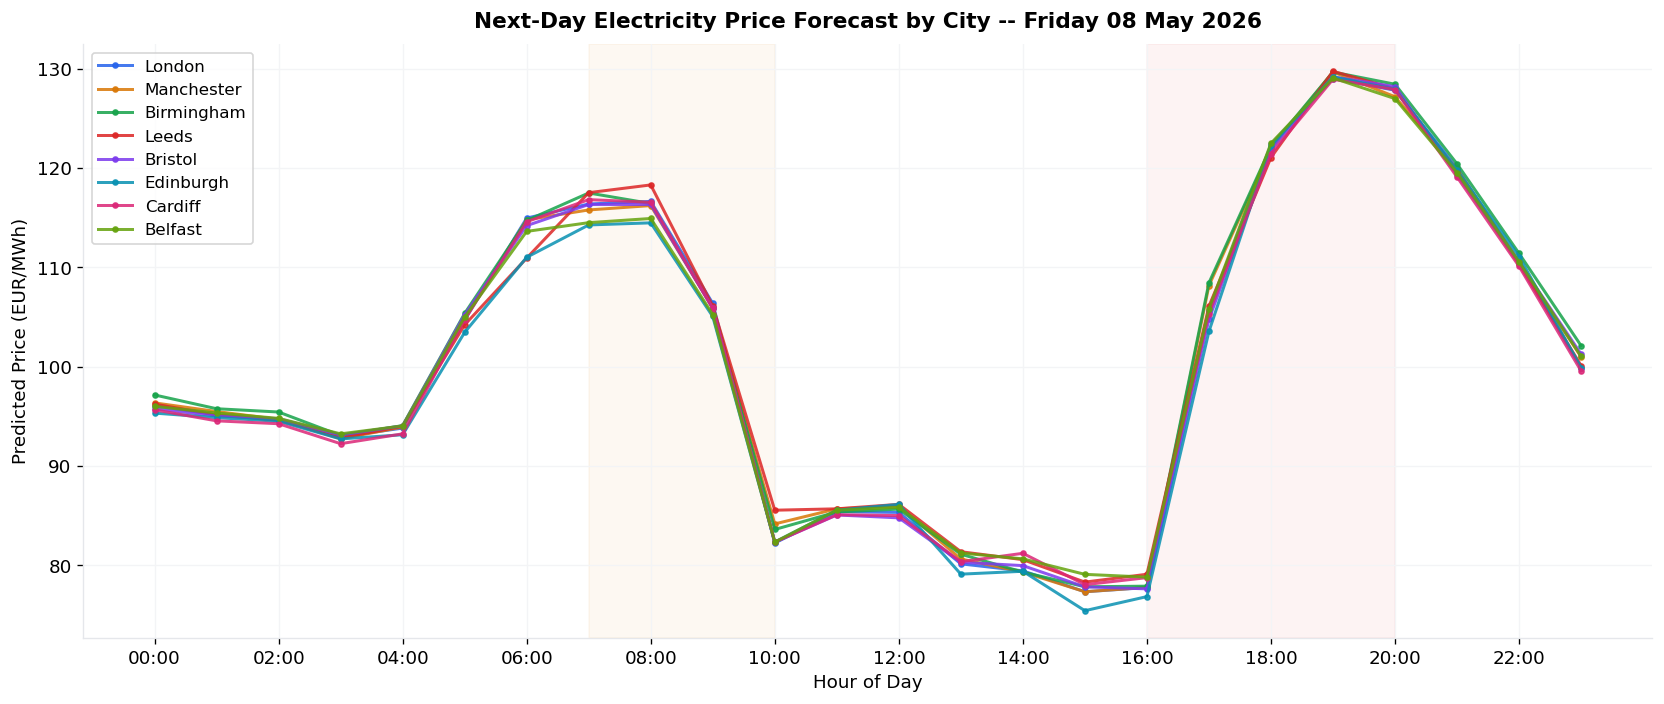

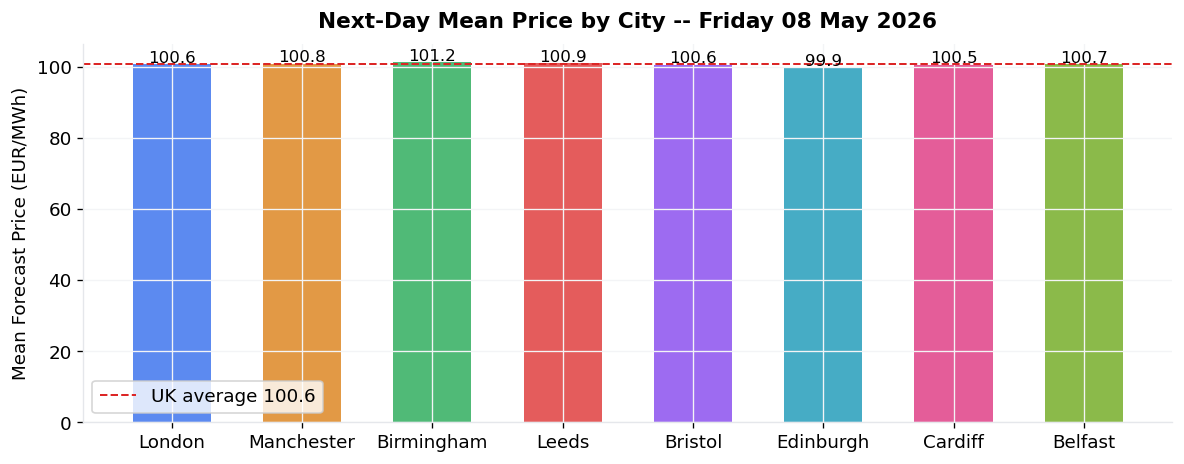

In [14]:
colors = [BLUE, AMBER, GREEN, RED, "#7c3aed", "#0891b2", "#db2777", "#65a30d"]
hours  = list(range(24))

fig, ax = plt.subplots(figsize=(14, 6))

for i, city in enumerate(UK_CITIES):
    name = city["name"]
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    ax.plot(hours, fc["price"].values,
            color=colors[i % len(colors)],
            linewidth=1.8, label=name, marker="o", markersize=3, alpha=0.85)

ax.axvspan(7, 10, alpha=0.05, color=AMBER)
ax.axvspan(16, 20, alpha=0.05, color=RED)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Predicted Price (EUR/MWh)")
fc_sample = list(city_forecasts.values())[0]
pred_date = fc_sample["pred_dt"].iloc[0].strftime("%A %d %B %Y")
ax.set_title(f"Next-Day Electricity Price Forecast by City -- {pred_date}")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig("city_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

# City comparison bar chart
city_means = {n: city_forecasts[n]["price"].mean()
              for n in city_forecasts}
fig2, ax2 = plt.subplots(figsize=(10, 4))
names  = list(city_means.keys())
values = list(city_means.values())
bar_colors = [colors[i % len(colors)] for i in range(len(names))]
bars = ax2.bar(names, values, color=bar_colors, alpha=0.75, width=0.6)
ax2.axhline(np.mean(values), color=RED, linewidth=1.2, linestyle="--",
            label=f"UK average {np.mean(values):.1f}")
ax2.set_ylabel("Mean Forecast Price (EUR/MWh)")
ax2.set_title(f"Next-Day Mean Price by City -- {pred_date}")
ax2.legend()
for bar, val in zip(bars, values):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("city_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


City:  London
Rows:  20,373
MAE:   19.36 EUR/MWh
R2:    0.342
Bias:  -3.03 EUR/MWh


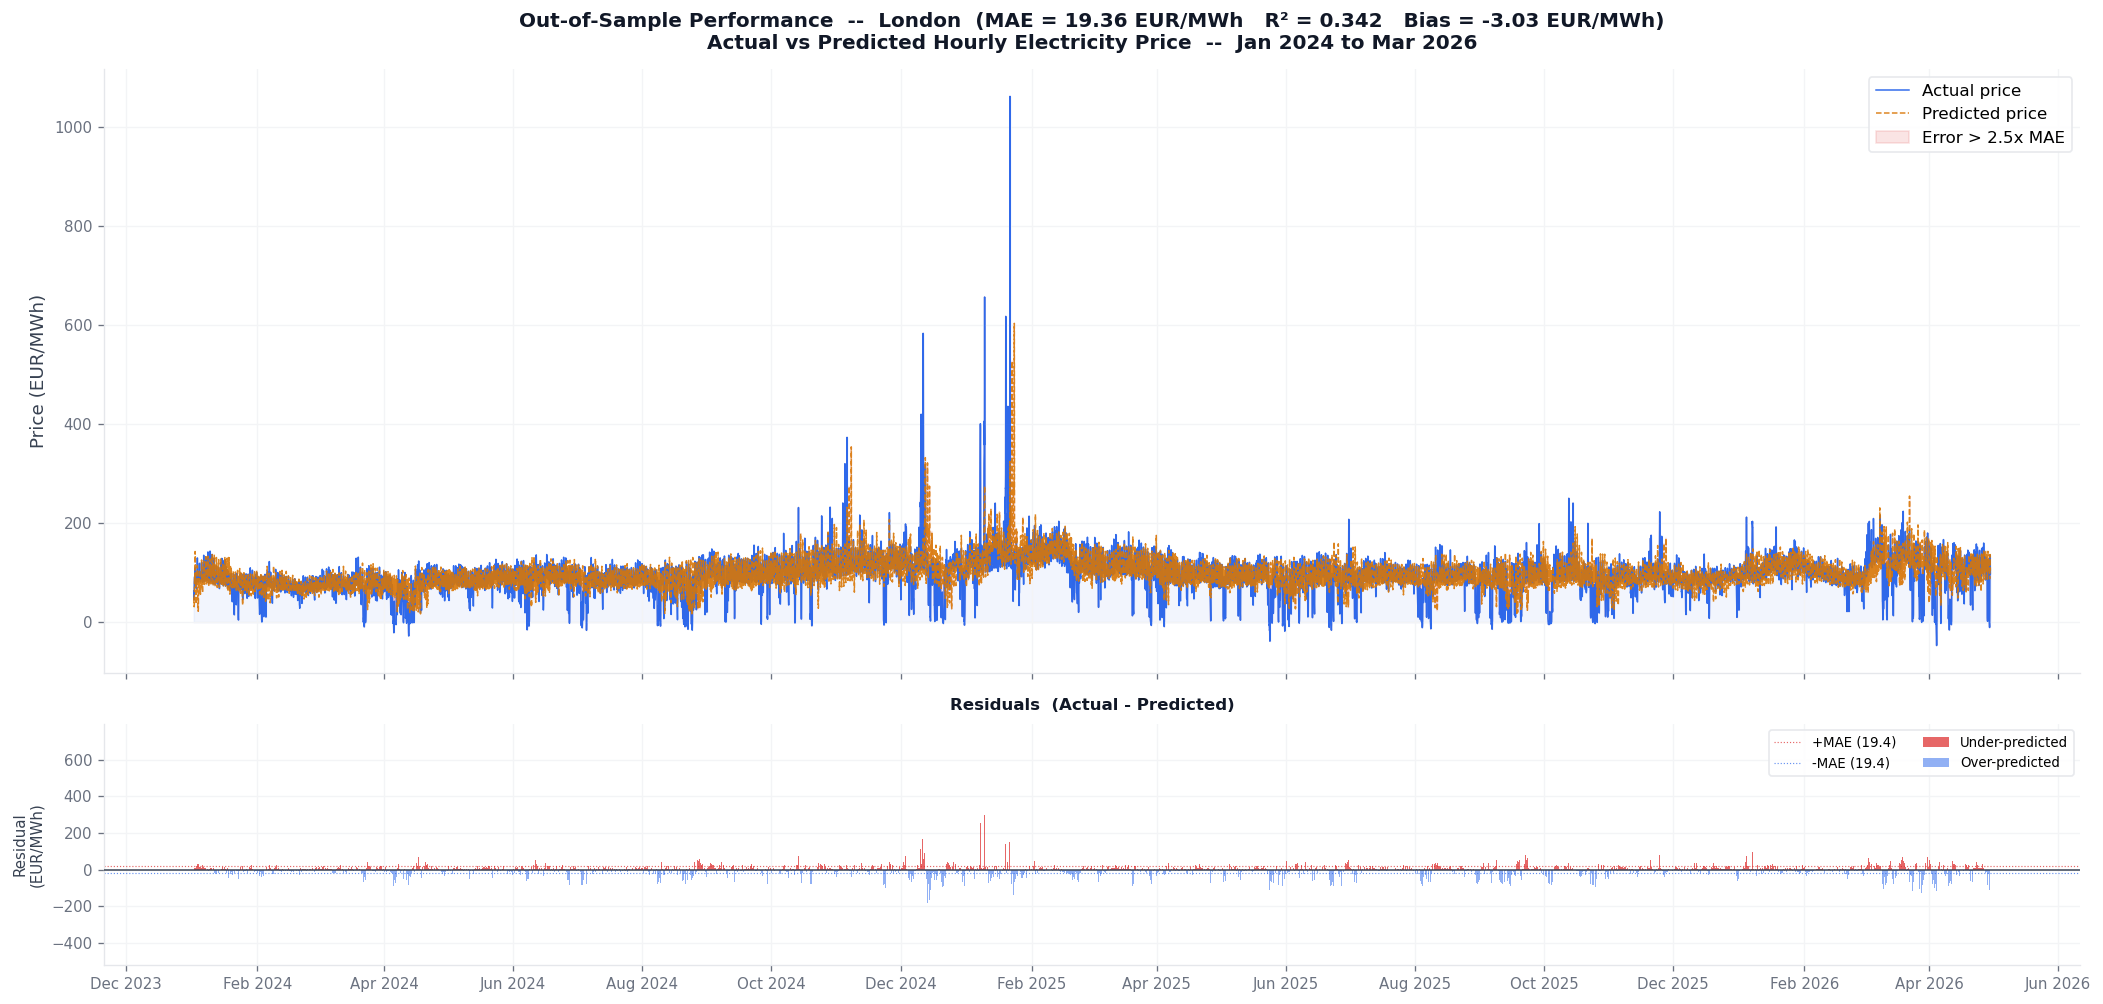

Saved: avp_residuals_london.png


In [15]:
# ── Actual vs Predicted + Residuals -- sample city, test period ───────────────

SAMPLE_CITY = "London"   # change to any city in UK_CITIES

if SAMPLE_CITY not in city_weather:
    print(f"{SAMPLE_CITY} weather not available -- run Step 8 first.")
else:
    wx = city_weather[SAMPLE_CITY].copy()

    # Test period electricity prices
    te_elec = elec[elec["dt"] >= SPLIT][["dt", "price"]].copy()

    # Merge test prices with city weather
    merged = te_elec.merge(wx, on="dt", how="left")
    for col in ["temp", "wind", "solar", "humidity", "precip"]:
        if col not in merged.columns:
            merged[col] = 0.0
        else:
            merged[col] = merged[col].ffill().bfill().fillna(0.0)

    # Pull lag/rolling/calendar features from precomputed test df
    lag_cols = [c for c in FCOLS
                if "p_lag" in c or "p_roll" in c or "vol_regime" in c]
    cal_cols = [c for c in FCOLS
                if c not in lag_cols
                and c not in ["temp","wind","solar","humidity","precip",
                               "hdd","wind_sq","temp_lag24","wind_lag24"]]

    te_base = df[te][["dt"] + lag_cols + cal_cols + ["target"]].copy()
    full    = te_base.merge(
        merged[["dt","temp","wind","solar","humidity","precip"]],
        on="dt", how="left"
    )

    full["hdd"]        = np.maximum(0, 15.5 - full["temp"].fillna(12))
    full["wind_sq"]    = full["wind"].fillna(0) ** 2
    full["temp_lag24"] = full["temp"].shift(24)
    full["wind_lag24"] = full["wind"].shift(24)

    valid  = full.dropna(subset=FCOLS + ["target"]).copy()
    preds  = rf.predict(valid[FCOLS])
    actual = valid["target"].values
    dates  = pd.to_datetime(valid["dt"])
    resids = actual - preds

    mae_city = float(np.mean(np.abs(resids)))
    r2_city  = float(1 - np.sum(resids**2) / np.sum((actual - actual.mean())**2))
    bias     = float(resids.mean())

    print(f"City:  {SAMPLE_CITY}")
    print(f"Rows:  {len(valid):,}")
    print(f"MAE:   {mae_city:.2f} EUR/MWh")
    print(f"R2:    {r2_city:.3f}")
    print(f"Bias:  {bias:+.2f} EUR/MWh")

    fig = plt.figure(figsize=(18, 9))
    fig.patch.set_facecolor("white")

    gs = fig.add_gridspec(
        2, 1,
        height_ratios=[3, 1.2],
        hspace=0.12,
        left=0.055, right=0.97,
        top=0.90,   bottom=0.07,
    )

    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    for ax in [ax_top, ax_bot]:
        ax.set_facecolor("white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color("#e5e7eb")
        ax.spines["left"].set_color("#e5e7eb")
        ax.tick_params(colors="#6b7280", labelsize=9)
        ax.yaxis.label.set_color("#374151")
        ax.xaxis.label.set_color("#374151")
        ax.grid(True, color="#f3f4f6", linewidth=0.8, linestyle="-")

    # ── Top panel: actual vs predicted ────────────────────────────────────────
    ax_top.fill_between(dates, actual, alpha=0.06, color=BLUE)
    ax_top.plot(dates, actual, color=BLUE,  linewidth=0.9,
                label="Actual price",      alpha=0.95, zorder=3)
    ax_top.plot(dates, preds,  color=AMBER, linewidth=0.9,
                linestyle="--", label="Predicted price", alpha=0.90, zorder=4)

    # Shade the biggest error regions to draw attention
    big_err = np.abs(resids) > mae_city * 2.5
    ax_top.fill_between(dates, actual, preds,
                        where=big_err,
                        alpha=0.12, color=RED, label="Error > 2.5x MAE")

    ax_top.set_ylabel("Price (EUR/MWh)", fontsize=11)
    ax_top.set_title(
        f"Out-of-Sample Performance  --  {SAMPLE_CITY}  "
        f"(MAE = {mae_city:.2f} EUR/MWh   R\u00b2 = {r2_city:.3f}   "
        f"Bias = {bias:+.2f} EUR/MWh)\n"
        f"Actual vs Predicted Hourly Electricity Price  --  Jan 2024 to Mar 2026",
        fontsize=12, pad=12, color="#111827",
    )
    ax_top.legend(fontsize=10, loc="upper right",
                  framealpha=0.9, edgecolor="#e5e7eb")
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # ── Bottom panel: residuals ───────────────────────────────────────────────
    pos = resids > 0
    neg = resids <= 0
    ax_bot.bar(dates[pos], resids[pos], width=0.04,
               color=RED,    alpha=0.70, zorder=3, label="Under-predicted")
    ax_bot.bar(dates[neg], resids[neg], width=0.04,
               color=BLUE,   alpha=0.50, zorder=3, label="Over-predicted")

    ax_bot.axhline(0,          color="#374151", linewidth=0.9, zorder=5)
    ax_bot.axhline( mae_city,  color=RED,  linewidth=0.7, linestyle=":",
                   alpha=0.7, label=f"+MAE ({mae_city:.1f})")
    ax_bot.axhline(-mae_city,  color=BLUE, linewidth=0.7, linestyle=":",
                   alpha=0.7, label=f"-MAE ({mae_city:.1f})")

    ax_bot.set_ylabel("Residual\n(EUR/MWh)", fontsize=9)
    ax_bot.set_title("Residuals  (Actual - Predicted)",
                     fontsize=10, pad=8, color="#111827")
    ax_bot.legend(fontsize=8, loc="upper right",
                  ncol=2, framealpha=0.9, edgecolor="#e5e7eb")

    # Monthly x-axis ticks
    ax_bot.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax_bot.get_xticklabels(), rotation=0, ha="center",
             fontsize=9, color="#6b7280")

    fname = "avp_residuals_" + SAMPLE_CITY.lower() + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: " + fname)


## Step 12 -- Save Results for Streamlit Dashboard

Saves `city_forecasts.json` which the Streamlit app reads automatically.
Run this cell each time you want to refresh the dashboard with new predictions.


In [16]:
def safe_float(v):
    """
    Safely convert a value to a rounded float.

    Handles:
    - NaN values
    - infinite values
    - invalid conversions

    Returns 0.0 if value is not valid.
    """
    try:
        f = float(v)
        return 0.0 if (f != f or abs(f) == float("inf")) else round(f, 2)
    except:
        return 0.0
# Build final export dictionary
output = {
    "generated_at":  pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),  # Timestamp of generation
    "pred_date":     list(city_forecasts.values())[0]["pred_dt"].iloc[0].strftime("%Y-%m-%d"), # Prediction date (same for all cities)
    "pred_date_str": list(city_forecasts.values())[0]["pred_dt"].iloc[0].strftime("%A %d %B %Y"),  #readable date format
    "model_mae":     round(mae, 2),  # Model performance metrics
    "model_r2":      round(r2, 3), 
    "cities":        [], # Container for city-level results
}
# Aggregate forecasts per city
for city in UK_CITIES:
    name = city["name"]
    # Skip if no forecast available
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    # Identify peak and minimum price hours
    peak_idx = fc["price"].idxmax()
    low_idx  = fc["price"].idxmin()
    # Store structured city data
    output["cities"].append({
        # Basic metadata
        "name":       name,
        "region":     city["region"],
        "lat":        city["lat"],
        "lon":        city["lon"],
        # Summary statistics
        "mean_price": safe_float(fc["price"].mean()),
        "peak_price": safe_float(fc["price"].max()),
        "peak_hour":  int(fc.loc[peak_idx, "hour"]),
        "low_price":  safe_float(fc["price"].min()),
        "low_hour":   int(fc.loc[low_idx, "hour"]),
        "day_range":  safe_float(fc["price"].max() - fc["price"].min()),
        # Full hourly time series
        "hours":      [int(h) for h in fc["hour"]],
        "prices":     [safe_float(p) for p in fc["price"]],
        "temps":      [safe_float(t) for t in fc["temp"]],
        "winds":      [safe_float(w) for w in fc["wind"]],
        "solars":     [safe_float(s) for s in fc["solar"]],
    })
# Save JSON output file
with open("city_forecasts.json", "w") as f:
    json.dump(output, f, indent=2)
#File size + summary report
size = os.path.getsize("city_forecasts.json")
print(f"city_forecasts.json saved ({size} bytes)")
print(f"Generated at: {output['generated_at']}")
print(f"Forecast for: {output['pred_date_str']}")
print(f"Cities saved: {len(output['cities'])}")
print()
print("Run app.py to see the dashboard:  streamlit run app.py")


city_forecasts.json saved (17472 bytes)
Generated at: 2026-05-07 21:30
Forecast for: Friday 08 May 2026
Cities saved: 8

Run app.py to see the dashboard:  streamlit run app.py
